In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv("data/invoices.csv")
print(df.shape)
df.head()


(2000, 8)


,invoice_id,supplier_id,amount,days_to_pay,num_items,weekend_submission,is_duplicate,is_fraud
0,INV1000,SUP21,5553.04,58,5,1,0,0
1,INV1001,SUP40,8.06,0,1,0,0,1
2,INV1002,SUP50,19668.69,18,18,0,0,0
3,INV1003,SUP24,6193.27,20,4,0,0,0
4,INV1004,SUP47,7993.13,56,14,0,0,0


Fraud rate: 0.073


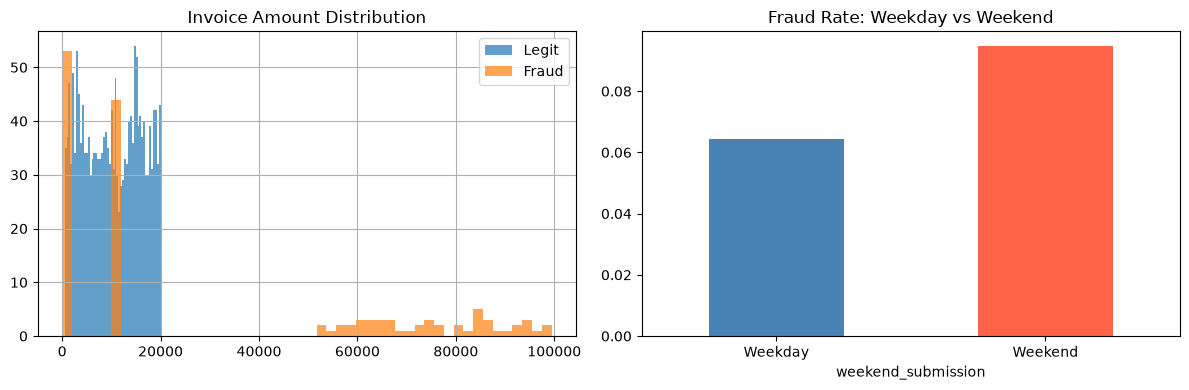

In [4]:
print("Fraud rate:", df['is_fraud'].mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['is_fraud']==0]['amount'].hist(ax=axes[0], bins=50, alpha=0.7, label='Legit')
df[df['is_fraud']==1]['amount'].hist(ax=axes[0], bins=50, alpha=0.7, label='Fraud')
axes[0].set_title('Invoice Amount Distribution')
axes[0].legend()

fraud_weekend = df.groupby('weekend_submission')['is_fraud'].mean()
fraud_weekend.plot(kind='bar', ax=axes[1], color=['steelblue','tomato'])
axes[1].set_title('Fraud Rate: Weekday vs Weekend')
axes[1].set_xticklabels(['Weekday', 'Weekend'], rotation=0)

plt.tight_layout()
plt.savefig('eda_plot.png')
plt.show()

In [5]:
features = ['amount', 'days_to_pay', 'num_items', 'weekend_submission', 'is_duplicate']
X = df[features]
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       371
           1       1.00      1.00      1.00        29

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



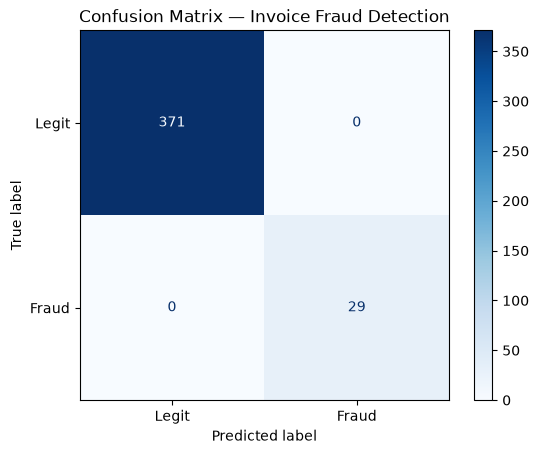

In [6]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit','Fraud'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Invoice Fraud Detection')
plt.savefig('confusion_matrix.png')
plt.show()

()

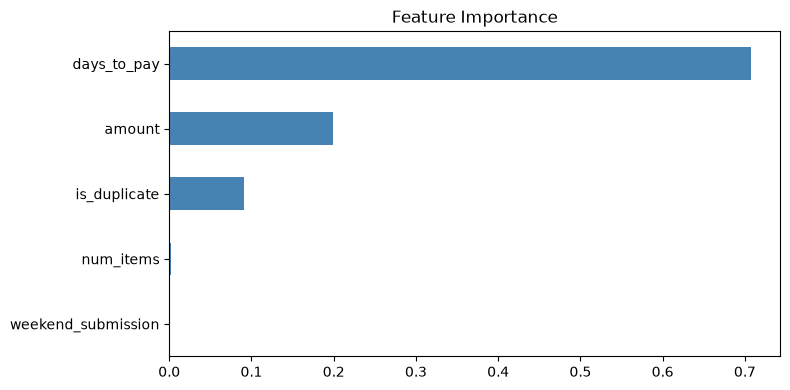

In [7]:
importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='steelblue', figsize=(8,4))
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show
()